In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import io

# Download and unzip the CSV directly
url = "https://coastal.er.usgs.gov/data-release/doi-P9XJRW5O/data/25_Year_KeyWest_Seafloor_Projection_MeanErosion.zip"
urllib.request.urlretrieve(url, "erosion_data.zip")

with zipfile.ZipFile("erosion_data.zip", "r") as z:
    print(z.namelist())  # see what's inside
    csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
    with z.open(csv_name) as f:
        df = pd.read_csv(f)

print(df.head())
print(df.columns.tolist())

['25_Year_KeyWest_Seafloor_Projection_MeanErosion.csv', '25_Year_KeyWest_Seafloor_Projection_MeanErosion_metadata.txt', '25_Year_KeyWest_Seafloor_Projection_MeanErosion_metadata.xml']
                  Study site: Key West  \
0                     Total study site   
1                       Aggregate reef   
2                   Colonized pavement   
3                Dredged and excavated   
4  Individual or aggregated patch reef   

   Mean projected erosion 25 years from 2002 in the Upper Florida Keys (m/25 years)  \
0                                            -0.2097                                  
1                                            -0.3077                                  
2                                            -0.3630                                  
3                                            -0.2097                                  
4                                            -0.2938                                  

   Max elevation in the 25 year Key West

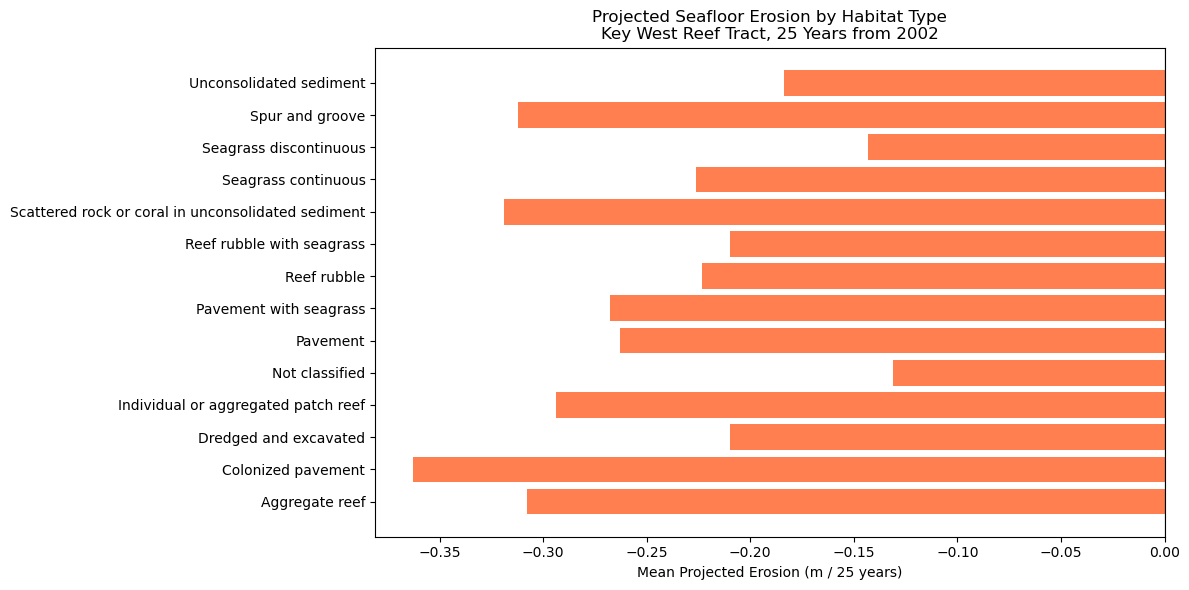

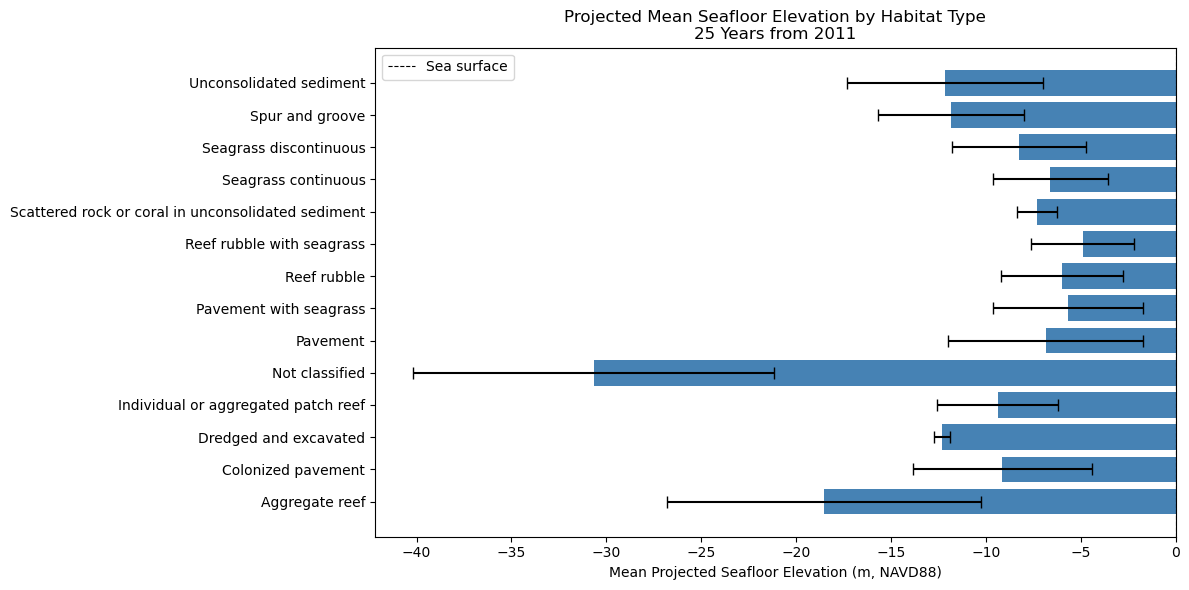

In [2]:
# Rename columns for convenience
df.columns = ['habitat', 'mean_erosion', 'max_elev', 'min_elev', 'mean_elev', 'sd']

# Drop any summary/total rows if needed
df = df[df['habitat'] != 'Total study site']

# Plot 1: Mean erosion rate by habitat type
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(df['habitat'], df['mean_erosion'], color='coral')
ax.set_xlabel('Mean Projected Erosion (m / 25 years)')
ax.set_title('Projected Seafloor Erosion by Habitat Type\nKey West Reef Tract, 25 Years from 2002')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Plot 2: Mean projected elevation with error bars (SD)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(df['habitat'], df['mean_elev'], xerr=df['sd'], color='steelblue', capsize=4)
ax.set_xlabel('Mean Projected Seafloor Elevation (m, NAVD88)')
ax.set_title('Projected Mean Seafloor Elevation by Habitat Type\n25 Years from 2011')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', label='Sea surface')
ax.legend()
plt.tight_layout()
plt.show()